<a href="https://colab.research.google.com/github/hmsuleyman-svg/Hafsa-Thesis-Notebook/blob/main/Hafsa_notebook_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import random
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [ ]:
# Read in data
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Thesis/acs_2024_income_full.csv")
df.head()

Mounted at /content/drive


,PINCP,AGEP,SEX,RAC1P,HISP,NATIVITY,CIT,YOEP,ENG,SCHL,...,FER,DIS,DEAR,DEYE,DREM,DPHY,PUMA,POWPUMA,JWMNP,MIL
0,18500.0,59,1,2,1,1,1,NaN,NaN,10.0,...,NaN,1,1,2,2.0,2.0,2500,NaN,NaN,4.0
1,0.0,43,1,1,1,1,1,NaN,NaN,17.0,...,NaN,2,2,2,2.0,2.0,2600,NaN,NaN,4.0
2,27100.0,75,2,2,1,1,1,NaN,NaN,16.0,...,NaN,1,2,2,2.0,1.0,1401,NaN,NaN,4.0
3,1000.0,22,2,6,1,1,3,2009.0,1.0,19.0,...,2.0,2,2,2,2.0,2.0,2802,NaN,NaN,4.0
4,0.0,51,1,1,1,1,1,NaN,NaN,16.0,...,NaN,2,2,2,2.0,2.0,800,NaN,NaN,4.0


In [ ]:
# Restrict to income > 0
df = df[df['PINCP'] > 1000].copy()

# Log-transform income
df['log_income'] = np.log(df['PINCP'])

# Winsorize income
low = df['log_income'].quantile(0.01)
high = df['log_income'].quantile(0.99)

df['log_income'] = df['log_income'].clip(lower=low, upper=high)

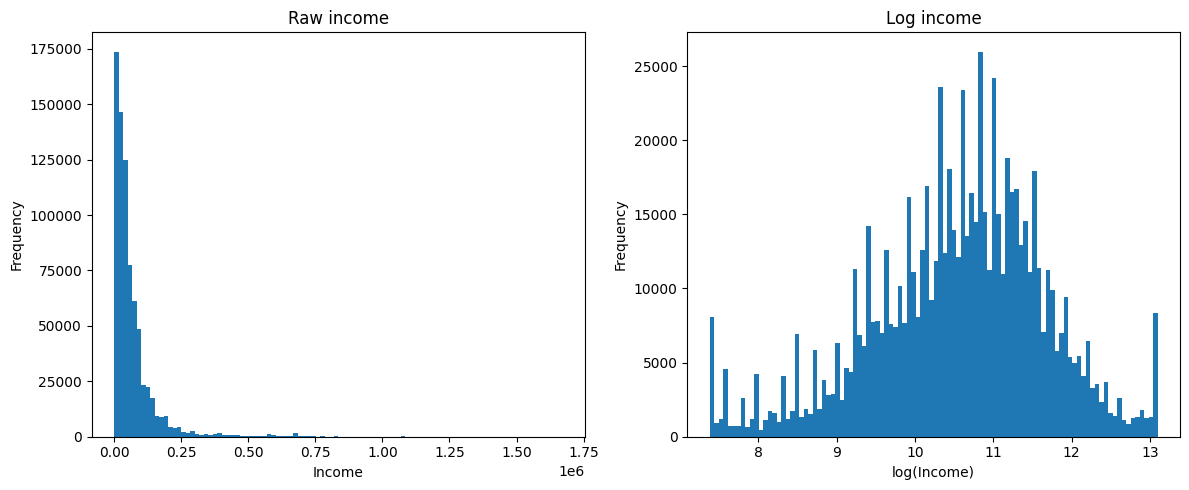

In [ ]:
# Inspect income distribution
plt.figure(figsize=(12, 5))

# Raw income
plt.subplot(1, 2, 1)
plt.hist(df['PINCP'], bins=100)
plt.title('Raw income')
plt.xlabel('Income')
plt.ylabel('Frequency')

# Log-transformed income
plt.subplot(1, 2, 2)
plt.hist(df['log_income'], bins=100)
plt.title('Log income')
plt.xlabel('log(Income)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Inspect NAs
df.isna().sum()

# Remove rows with no value for response variable
df = df.dropna(subset=["log_income"])

# Fix NAs for predictors
df["WKHP"] = df["WKHP"].fillna(0) # If someone has no recorded work hours, 0 is reasonable.
df["COW"] = df["COW"].fillna("not_working") # No class of worker often means not working / not applicable.
df['ENG'] = df['ENG'].fillna(1) # Missing means English is spoken very well/native in this coding scheme.

# Package-matched version: do NOT filter on ESR/employment status.
df = df.dropna(subset=['SCHL']) # Only a few missing values, let's just remove these observations

df.head()

,PINCP,AGEP,SEX,RAC1P,HISP,NATIVITY,CIT,YOEP,ENG,SCHL,...,DIS,DEAR,DEYE,DREM,DPHY,PUMA,POWPUMA,JWMNP,MIL,log_income
0,18500.0,59,1,2,1,1,1,NaN,1.0,10.0,...,1,1,2,2.0,2.0,2500,NaN,NaN,4.0,9.825526
2,27100.0,75,2,2,1,1,1,NaN,1.0,16.0,...,1,2,2,2.0,1.0,1401,NaN,NaN,4.0,10.207289
6,16400.0,66,1,2,1,1,1,NaN,1.0,1.0,...,1,2,2,1.0,2.0,1700,NaN,NaN,4.0,9.705037
7,30000.0,28,1,2,1,1,1,NaN,1.0,18.0,...,1,2,2,2.0,1.0,1404,NaN,NaN,2.0,10.308953
8,5100.0,18,2,2,1,1,1,NaN,1.0,16.0,...,2,2,2,2.0,2.0,2803,NaN,NaN,4.0,8.536996


In [ ]:
# Restrict to White, Black, and Asian
race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "Other",
    6: "Asian",
    7: "Native Hawaiian and Other Pacific Islander",
    8: "Other",
    9: "Other"
}

df['race'] = df['RAC1P'].map(race_map)

df = df[df['race'].isin([
    "White",
    "Black",
    "Asian"
])].copy()

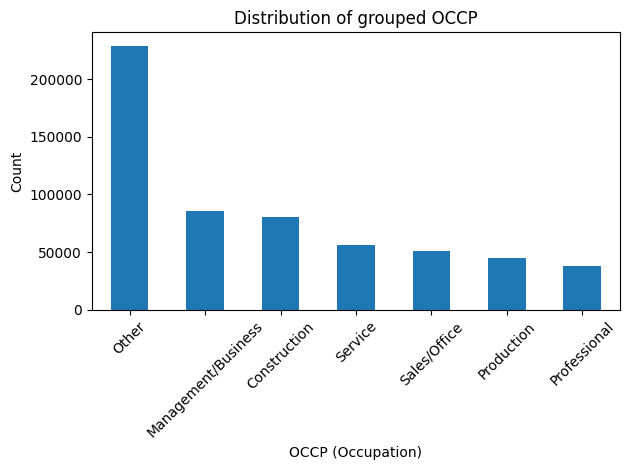

In [ ]:
# Make grouped version of occupation
def group_occp(code):
    if pd.isna(code):
        return "Other"

    code = int(code)

    if 10 <= code < 1000:
        return "Management/Business"
    elif 1000 <= code < 2000:
        return "Professional"
    elif 2000 <= code < 3000:
        return "Service"
    elif 3000 <= code < 4000:
        return "Sales/Office"
    elif 4000 <= code < 5000:
        return "Construction"
    elif 5000 <= code < 6000:
        return "Production"
    else:
        return "Other"

df['OCCP'] = df['OCCP'].apply(group_occp)
df['OCCP'].value_counts()

# Plot
df['OCCP'].value_counts().plot(kind='bar')
plt.xlabel('OCCP (Occupation)')
plt.ylabel('Count')
plt.title('Distribution of grouped OCCP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Recode SEX
df['SEX'] = df['SEX'].map({1: 'Male', 2: 'Female'})

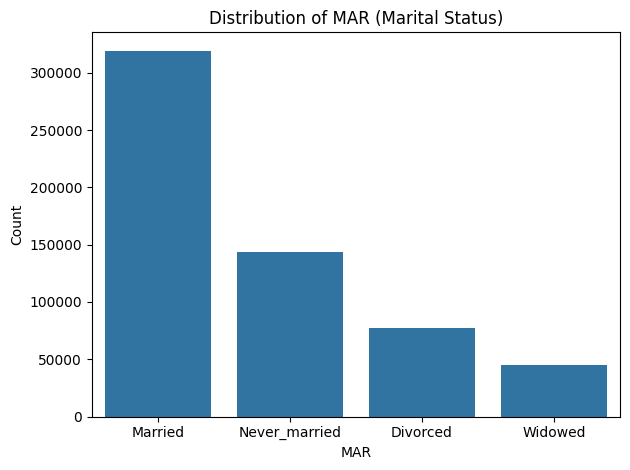

In [ ]:
# Recode MAR
def group_mar(x):
    if x == 1:
        return "Married"
    elif x == 5:
        return "Never_married"
    elif x in [3, 4]:
        return "Divorced"
    elif x == 2:
        return "Widowed"
    else:
        return "Other"

df['MAR'] = df['MAR'].apply(group_mar)

# Plot
plt.figure()
sns.countplot(data=df, x='MAR', order=df['MAR'].value_counts().index)
plt.title('Distribution of MAR (Marital Status)')
plt.xlabel('MAR')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

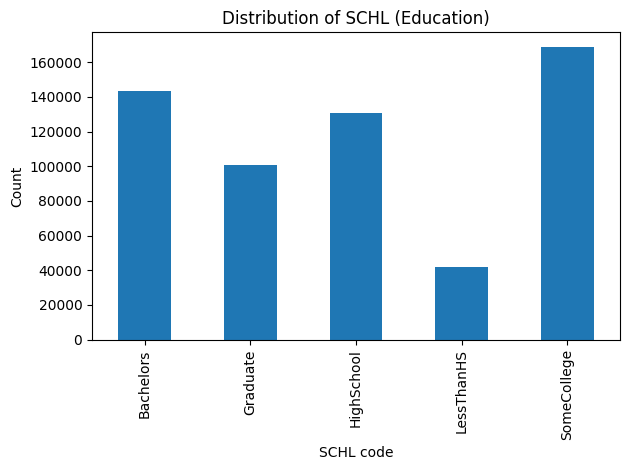

In [ ]:
# Recode SCHL
def group_schl(x):
    x = int(x)

    if x <= 15:
        return "LessThanHS"
    elif x in [16, 17]:
        return "HighSchool"
    elif 18 <= x <= 20:
        return "SomeCollege"
    elif x == 21:
        return "Bachelors"
    elif 22 <= x <= 24:
        return "Graduate"
    else:
        return "Other"

df['SCHL'] = df['SCHL'].apply(group_schl)

# Plot$
plt.figure()
df['SCHL'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of SCHL (Education)')
plt.xlabel('SCHL code')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

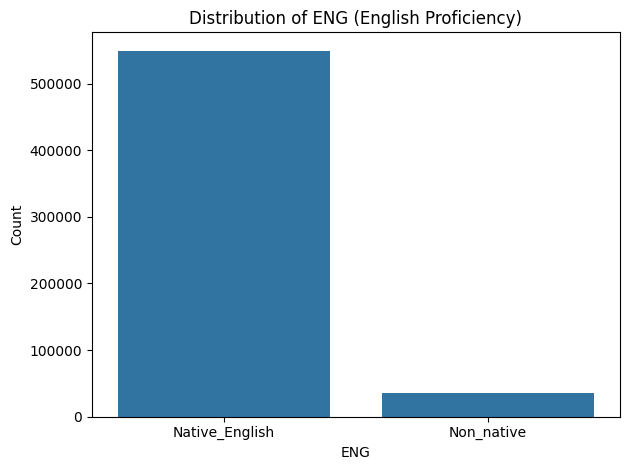

In [ ]:
# Recode ENG
def recode_eng(x):
    x = int(x)

    if x == 1:
        return "Native_English"
    else:
        return "Non_native"

df['ENG'] = df['ENG'].apply(recode_eng)

# Plot
plt.figure()
sns.countplot(data=df, x='ENG', order=df['ENG'].value_counts().index)
plt.title('Distribution of ENG (English Proficiency)')
plt.xlabel('ENG')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

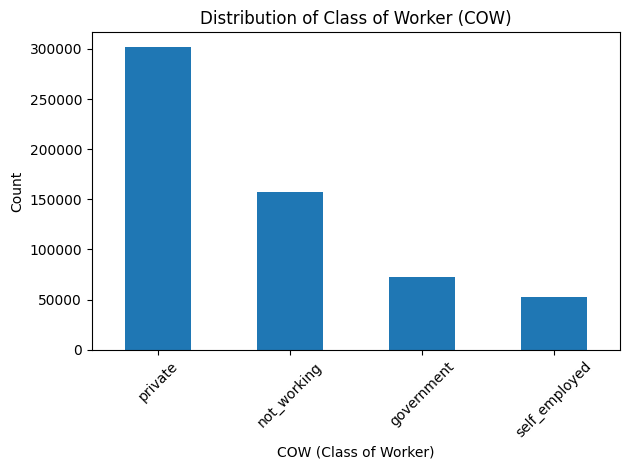

In [ ]:
# Recode COW
cow_map = {
    1.0: 'private',
    2.0: 'private',
    3.0: 'government',
    4.0: 'government',
    5.0: 'government',
    6.0: 'self_employed',
    7.0: 'self_employed',
    8.0: 'unpaid_family',
    9.0: 'not_working',
    'not_working': 'not_working'
}
df['COW'] = df['COW'].replace(cow_map)

# Package-matched version: remove unpaid family only; keep not_working.
df = df[df['COW'] != 'unpaid_family'].copy()

# Plot
df['COW'].value_counts().plot(kind='bar')
plt.xlabel('COW (Class of Worker)')
plt.ylabel('Count')
plt.title('Distribution of Class of Worker (COW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Keep relevant columns only
cols_to_keep = [
    "log_income",
    "AGEP",
    "SEX",
    "race",
    "MAR",
    "SCHL",
    "WKHP",
    "COW",
    "OCCP",
    "ENG",
]

df = df[cols_to_keep]

df.head()

,log_income,AGEP,SEX,race,MAR,SCHL,WKHP,COW,OCCP,ENG
0,9.825526,59,Male,Black,Never_married,LessThanHS,30.0,private,Other,Native_English
2,10.207289,75,Female,Black,Divorced,HighSchool,0.0,not_working,Other,Native_English
6,9.705037,66,Male,Black,Never_married,LessThanHS,0.0,not_working,Other,Native_English
7,10.308953,28,Male,Black,Married,SomeCollege,72.0,private,Other,Native_English
8,8.536996,18,Female,Black,Never_married,HighSchool,20.0,private,Construction,Native_English


In [ ]:
# Rename columns
rename_dict = {
    "log_income": "LogIncome",
    "AGEP": "Age",
    "SEX": "Sex",
    "race": "Race",
    "MAR": "MaritalStatus",
    "SCHL": "Education",
    "WKHP": "HoursWorked",
    "COW": "ClassOfWorker",
    "OCCP": "Occupation",
    "ENG": "EnglishProficiency"
}

df = df.rename(columns=rename_dict)

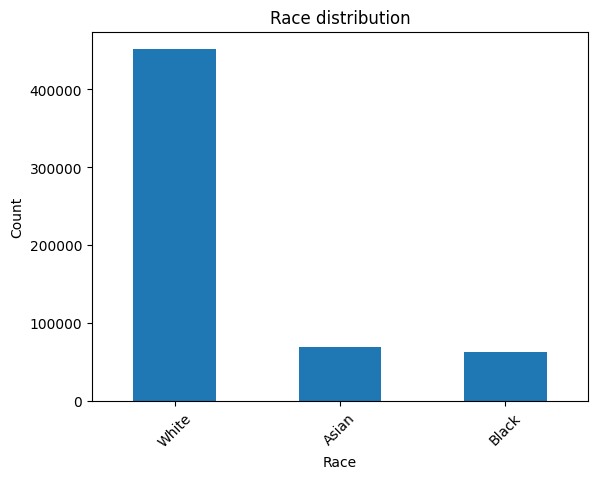

,count
Race,
White,451428
Asian,70233
Black,62590


In [ ]:
# Inspect race
df['Race'].value_counts().plot(kind='bar')
plt.title('Race distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

df['Race'].value_counts()

In [ ]:
race_before = df['Race'].copy()

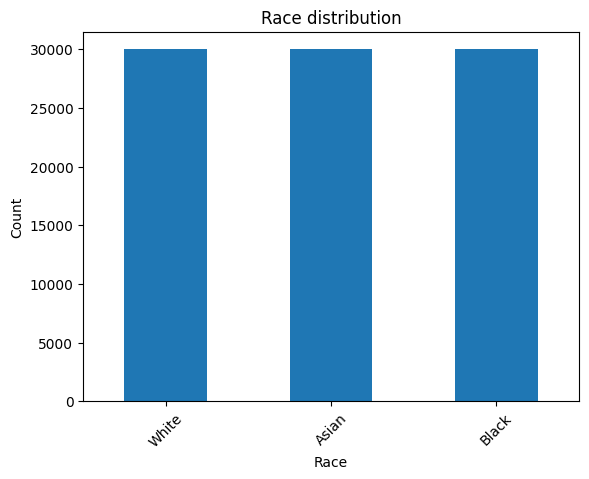

In [ ]:
# Randomly sample 30000 observations per race
# Package-matched version: use SEED=1 and do this once only.
df = (
    df.groupby('Race', group_keys=False)
      .sample(n=30000, random_state=SEED)
      .sample(frac=1, random_state=SEED)   # shuffle all rows
      .reset_index(drop=True)
)

# Inspect race
df['Race'].value_counts()

df['Race'].value_counts().plot(kind='bar')
plt.title('Race distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Duplicate downsampling removed for package-matched version.
# The balanced sample is already created in the previous cell.

In [ ]:
race_after = df['Race'].copy()

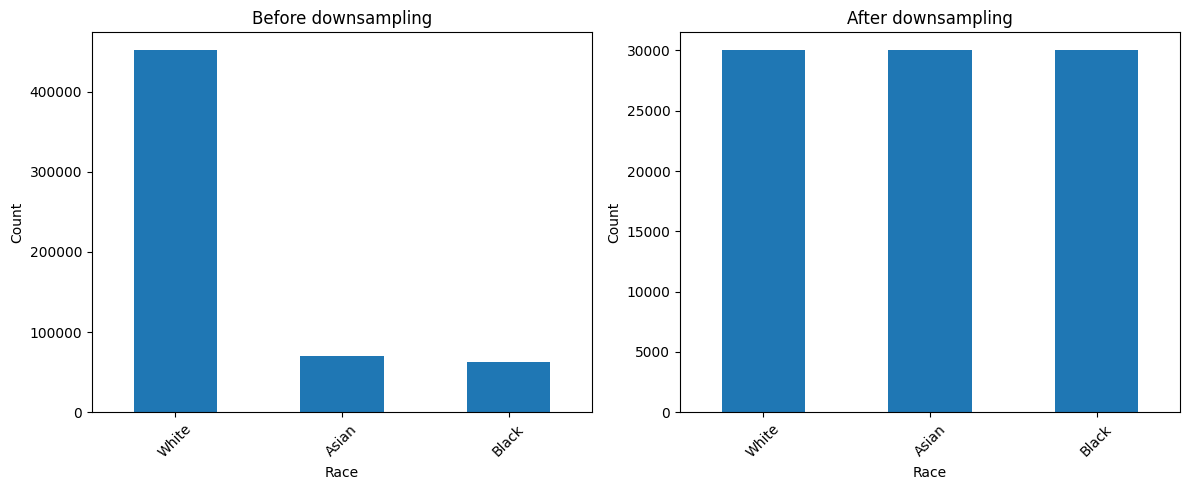

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

race_before.value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Before downsampling')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

race_after.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('After downsampling')
axes[1].set_xlabel('Race')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

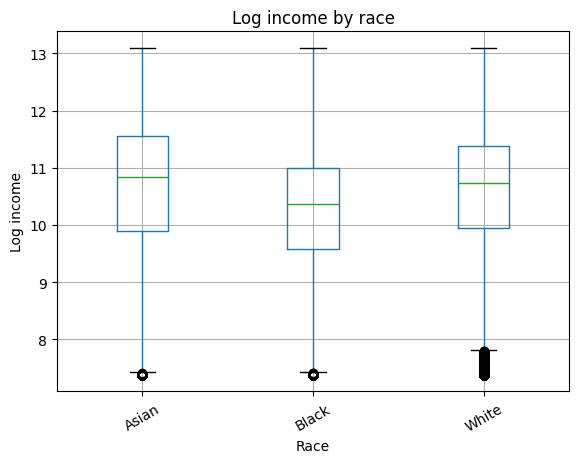

In [ ]:
# Inspect income by race
df.boxplot(column='LogIncome', by='Race', rot=30)
plt.title('Log income by race')
plt.suptitle('')
plt.ylabel('Log income')
plt.show()

In [ ]:
X = df.drop('LogIncome', axis=1)
y = df['LogIncome']
race = df['Race']

# Train vs temporary split
X_train, X_temp, y_train, y_temp, race_train, race_temp = train_test_split(
    X, y, race, test_size=0.30, random_state=SEED, stratify=race
)

# Validation vs test split
X_val, X_test, y_val, y_test, race_val, race_test = train_test_split(
    X_temp, y_temp, race_temp, test_size=0.50, random_state=SEED, stratify=race_temp
)

# Store race separately for adversarial debiasing
a_train = race_train.copy()
a_val = race_val.copy()
a_test = race_test.copy()

# Remove race for no-race models
X_train_no_race = X_train.drop(columns='Race').copy()
X_val_no_race = X_val.drop(columns='Race').copy()
X_test_no_race = X_test.drop(columns='Race').copy()

In [ ]:
# Define variable types
categorical_cols_with_race = [
    'Race', 'Occupation', 'ClassOfWorker', 'Sex', 'MaritalStatus', 'Education', 'EnglishProficiency'
]

categorical_cols_without_race = [
  'Occupation', 'ClassOfWorker', 'Sex', 'MaritalStatus', 'Education', 'EnglishProficiency'
]

numerical_cols = [
    'Age', 'HoursWorked'
]

# Define variable encoding
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
# Define preprocessors with and without race
preprocessor_race = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols_with_race)
])

preprocessor_no_race = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols_without_race)
])

In [ ]:
# Apply preprocessing: with race
X_train_race = preprocessor_race.fit_transform(X_train)
X_val_race = preprocessor_race.transform(X_val)
X_test_race = preprocessor_race.transform(X_test)

feature_names_race = preprocessor_race.get_feature_names_out()

X_train_race = pd.DataFrame(X_train_race, columns=feature_names_race, index=X_train.index)
X_val_race = pd.DataFrame(X_val_race, columns=feature_names_race, index=X_val.index)
X_test_race = pd.DataFrame(X_test_race, columns=feature_names_race, index=X_test.index)

# Apply preprocessing: no race
X_train_no_race = preprocessor_no_race.fit_transform(X_train_no_race)
X_val_no_race = preprocessor_no_race.transform(X_val_no_race)
X_test_no_race = preprocessor_no_race.transform(X_test_no_race)

feature_names_no_race = preprocessor_no_race.get_feature_names_out()

X_train_no_race = pd.DataFrame(X_train_no_race, columns=feature_names_no_race, index=X_train.index)
X_val_no_race = pd.DataFrame(X_val_no_race, columns=feature_names_no_race, index=X_val.index)
X_test_no_race = pd.DataFrame(X_test_no_race, columns=feature_names_no_race, index=X_test.index)

In [ ]:
# Package-matched model definitions

class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, dropout=0.2):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.regressor = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.regressor(features)
        return output, features


class RaceAdversary(nn.Module):
    def __init__(self, input_dim, num_race_classes, hidden_dim=16, dropout=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_race_classes)
        )

    def forward(self, x):
        return self.network(x)


class RaceProbe(nn.Module):
    def __init__(self, input_dim, num_race_classes, hidden_dim1=128, hidden_dim2=128, dropout=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, num_race_classes)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
# Baseline Model 1 using Pytorch

X_train_tensor = torch.tensor(X_train_race.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_race.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_race.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
# Model 1: +Race, -Adversary

g_train_race = torch.Generator().manual_seed(SEED)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g_train_race)

In [ ]:
# Model 1: +Race, -Adversary

torch.manual_seed(SEED)

input_dim = X_train_tensor.shape[1]
model = MLPRegressor(input_dim=input_dim, hidden_dim=16, dropout=0.2)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30

In [ ]:
# Model 1: +Race, -Adversary

best_val_mae = float("inf")
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred, _ = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        val_pred, _ = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor).item()
        val_mae = mean_absolute_error(
            y_val_tensor.cpu().numpy().ravel(),
            val_pred.cpu().numpy().ravel()
        )

    # Match the package: select the income model checkpoint by validation MAE.
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train MSE={train_loss:.4f}, Val MSE={val_loss:.4f}, Val MAE={val_mae:.4f}")

model.load_state_dict(best_model_state)
print(f"Best validation MAE: {best_val_mae:.4f}")

Epoch 10: Train MSE=1.6856, Val MSE=0.7186, Val MAE=0.6453
Epoch 20: Train MSE=0.8079, Val MSE=0.6830, Val MAE=0.6126
Epoch 30: Train MSE=0.7319, Val MSE=0.6845, Val MAE=0.6108
Best validation MAE: 0.6104


In [ ]:
# Evaluation Baseline Model 1 using Pytorch

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, name):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

model.eval()
with torch.no_grad():
    y_pred_train, h_train = model(X_train_tensor)
    y_pred_val, h_val     = model(X_val_tensor)
    y_pred_test, h_test   = model(X_test_tensor)

y_pred_train = y_pred_train.cpu().numpy().flatten()
y_pred_val   = y_pred_val.cpu().numpy().flatten()
y_pred_test  = y_pred_test.cpu().numpy().flatten()

evaluate_regression(y_train.values, y_pred_train, "Train")
evaluate_regression(y_val.values, y_pred_val, "Validation")
evaluate_regression(y_test.values, y_pred_test, "Test")


Train
MSE: 0.691779330825506
MAE: 0.611021343505048
R2: 0.48121090476786554

Validation
MSE: 0.685453876822974
MAE: 0.6104024734209702
R2: 0.4881622697772151

Test
MSE: 0.7054686643590687
MAE: 0.6168635504667769
R2: 0.47456822859327363


In [ ]:
# Model 3 Race excluded and Debiasing off
X_train_no_race_tensor = torch.tensor(X_train_no_race.values, dtype=torch.float32)
X_val_no_race_tensor   = torch.tensor(X_val_no_race.values, dtype=torch.float32)
X_test_no_race_tensor  = torch.tensor(X_test_no_race.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
# Model 3: -Race, -Adversary

g_train_no_race = torch.Generator().manual_seed(SEED)
train_dataset_no_race = TensorDataset(X_train_no_race_tensor, y_train_tensor)
train_loader_no_race = DataLoader(train_dataset_no_race, batch_size=64, shuffle=True, generator=g_train_no_race)

In [ ]:
# Model 3: -Race, -Adversary

torch.manual_seed(SEED)

input_dim_no_race = X_train_no_race_tensor.shape[1]
model_3 = MLPRegressor(input_dim=input_dim_no_race, hidden_dim=16, dropout=0.2)

criterion_3 = nn.MSELoss()
optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.001)

num_epochs = 30

In [ ]:
# Model 3: -Race, -Adversary

best_val_mae_3 = float("inf")
best_model_state_3 = None

for epoch in range(num_epochs):
    model_3.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_no_race:
        optimizer_3.zero_grad()
        y_pred, _ = model_3(X_batch)
        loss = criterion_3(y_pred, y_batch)
        loss.backward()
        optimizer_3.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader_no_race.dataset)

    model_3.eval()
    with torch.no_grad():
        val_pred, _ = model_3(X_val_no_race_tensor)
        val_loss = criterion_3(val_pred, y_val_tensor).item()
        val_mae = mean_absolute_error(
            y_val_tensor.cpu().numpy().ravel(),
            val_pred.cpu().numpy().ravel()
        )

    # Match the package: select the income model checkpoint by validation MAE.
    if val_mae < best_val_mae_3:
        best_val_mae_3 = val_mae
        best_model_state_3 = copy.deepcopy(model_3.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train MSE={train_loss:.4f}, Val MSE={val_loss:.4f}, Val MAE={val_mae:.4f}")

model_3.load_state_dict(best_model_state_3)
print(f"Best validation MAE: {best_val_mae_3:.4f}")

Epoch 10: Train MSE=1.7114, Val MSE=0.7197, Val MAE=0.6469
Epoch 20: Train MSE=0.8025, Val MSE=0.6901, Val MAE=0.6168
Epoch 30: Train MSE=0.7454, Val MSE=0.6932, Val MAE=0.6173
Best validation MAE: 0.6150


In [ ]:
#Evaluate model 3
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, name):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

model_3.eval()
with torch.no_grad():
    y_pred_train_3, h_train_3 = model_3(X_train_no_race_tensor)
    y_pred_val_3, h_val_3     = model_3(X_val_no_race_tensor)
    y_pred_test_3, h_test_3   = model_3(X_test_no_race_tensor)

y_pred_train_3 = y_pred_train_3.cpu().numpy().flatten()
y_pred_val_3   = y_pred_val_3.cpu().numpy().flatten()
y_pred_test_3  = y_pred_test_3.cpu().numpy().flatten()

print("MODEL 3: Race excluded, debiasing OFF")

evaluate_regression(y_train.values, y_pred_train_3, "Train")
evaluate_regression(y_val.values, y_pred_val_3, "Validation")
evaluate_regression(y_test.values, y_pred_test_3, "Test")

MODEL 3: Race excluded, debiasing OFF

Train
MSE: 0.698944997160241
MAE: 0.617310913317153
R2: 0.47583712531409605

Validation
MSE: 0.6882288422492783
MAE: 0.6149938984855061
R2: 0.4860901653610443

Test
MSE: 0.7096844834248461
MAE: 0.6216322492182779
R2: 0.47142829426086197


In [ ]:
# Model 2 and Model 4 use the same MLPRegressor feature extractor as the baseline models.
# The adversarial component is RaceAdversary, defined above.

In [ ]:
# Alias for compatibility with later code labels
Adversary = RaceAdversary

In [ ]:
# Encode race to integers for adversarial training and probe evaluation
race_encoder = LabelEncoder()

race_train_enc = race_encoder.fit_transform(race_train)
race_val_enc   = race_encoder.transform(race_val)
race_test_enc  = race_encoder.transform(race_test)

race_train_tensor = torch.tensor(race_train_enc, dtype=torch.long)
race_val_tensor   = torch.tensor(race_val_enc, dtype=torch.long)
race_test_tensor  = torch.tensor(race_test_enc, dtype=torch.long)

num_race_classes = len(race_encoder.classes_)

print("Race classes:", race_encoder.classes_)
print("Train shape:", race_train_tensor.shape)

Race classes: ['Asian' 'Black' 'White']
Train shape: torch.Size([63000])


In [ ]:
# Model 2 adversary preview
adversary_2 = RaceAdversary(input_dim=16, num_race_classes=num_race_classes, hidden_dim=16, dropout=0.2)

In [ ]:
# Model 2: +Race, +Adversary

torch.manual_seed(SEED)

input_dim = X_train_tensor.shape[1]

model_2 = MLPRegressor(input_dim=input_dim, hidden_dim=16, dropout=0.2)
adversary_2 = RaceAdversary(input_dim=16, num_race_classes=num_race_classes, hidden_dim=16, dropout=0.2)

income_criterion = nn.MSELoss()
race_criterion = nn.CrossEntropyLoss()

optimizer_main = torch.optim.Adam(model_2.parameters(), lr=0.001)
optimizer_adv = torch.optim.Adam(adversary_2.parameters(), lr=0.001)

num_epochs = 30
lambda_adv = 0.05

In [ ]:
# Model 2: +Race, +Adversary

g_train_adv = torch.Generator().manual_seed(SEED)
train_dataset_adv = TensorDataset(X_train_tensor, y_train_tensor, race_train_tensor)
train_loader_adv = DataLoader(train_dataset_adv, batch_size=64, shuffle=True, generator=g_train_adv)

In [ ]:
# Model 2: +Race, +Adversary

best_val_mae_2 = float("inf")
best_model_state_2 = None
best_adversary_state_2 = None

for epoch in range(num_epochs):
    model_2.train()
    adversary_2.train()

    total_income_loss = 0.0
    total_adv_loss = 0.0

    for X_batch, y_batch, race_batch in train_loader_adv:

        # 1. Train adversary on frozen features
        optimizer_adv.zero_grad()
        with torch.no_grad():
            _, frozen_features = model_2(X_batch)
        race_logits = adversary_2(frozen_features)
        adv_loss = race_criterion(race_logits, race_batch)
        adv_loss.backward()
        optimizer_adv.step()

        # 2. Train main model to predict income and make race harder to predict
        optimizer_main.zero_grad()
        income_pred, features = model_2(X_batch)
        race_logits_main = adversary_2(features)

        income_loss = income_criterion(income_pred, y_batch)
        adv_loss_main = race_criterion(race_logits_main, race_batch)
        main_loss = income_loss - lambda_adv * adv_loss_main

        main_loss.backward()
        optimizer_main.step()

        total_income_loss += income_loss.item() * X_batch.size(0)
        total_adv_loss += adv_loss.item() * X_batch.size(0)

    avg_income_loss = total_income_loss / len(train_loader_adv.dataset)
    avg_adv_loss = total_adv_loss / len(train_loader_adv.dataset)

    model_2.eval()
    adversary_2.eval()
    with torch.no_grad():
        val_income_pred, val_h = model_2(X_val_tensor)
        val_income_loss = income_criterion(val_income_pred, y_val_tensor).item()
        val_mae = mean_absolute_error(
            y_val_tensor.cpu().numpy().ravel(),
            val_income_pred.cpu().numpy().ravel()
        )
        val_race_logits = adversary_2(val_h)
        val_adv_loss = race_criterion(val_race_logits, race_val_tensor).item()

    # Match the package: select the income model checkpoint by validation MAE,
    # not by MSE, adversary CE, or the combined adversarial objective.
    if val_mae < best_val_mae_2:
        best_val_mae_2 = val_mae
        best_model_state_2 = copy.deepcopy(model_2.state_dict())
        best_adversary_state_2 = copy.deepcopy(adversary_2.state_dict())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train MSE={avg_income_loss:.4f}, "
            f"Train Adv CE={avg_adv_loss:.4f}, "
            f"Val MSE={val_income_loss:.4f}, "
            f"Val MAE={val_mae:.4f}, "
            f"Val Adv CE={val_adv_loss:.4f}"
        )

model_2.load_state_dict(best_model_state_2)
adversary_2.load_state_dict(best_adversary_state_2)
print(f"Best validation MAE: {best_val_mae_2:.4f}")

Epoch 10: Train MSE=1.7051, Train Adv CE=1.0766, Val MSE=0.7286, Val MAE=0.6542, Val Adv CE=1.0983
Epoch 20: Train MSE=0.8254, Train Adv CE=1.0673, Val MSE=0.6998, Val MAE=0.6251, Val Adv CE=1.0626
Epoch 30: Train MSE=0.7659, Train Adv CE=1.0594, Val MSE=0.7120, Val MAE=0.6252, Val Adv CE=1.0549
Best validation MAE: 0.6236


In [ ]:
#Model 2 Race included, Debiasing ON

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, name):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

model_2.eval()
with torch.no_grad():
    y_pred_train_2, h_train_2 = model_2(X_train_tensor)
    y_pred_val_2, h_val_2 = model_2(X_val_tensor)
    y_pred_test_2, h_test_2 = model_2(X_test_tensor)

y_pred_train_2 = y_pred_train_2.cpu().numpy().flatten()
y_pred_val_2 = y_pred_val_2.cpu().numpy().flatten()
y_pred_test_2 = y_pred_test_2.cpu().numpy().flatten()

print("MODEL 2: Race included, debiasing ON")

evaluate_regression(y_train.values, y_pred_train_2, "Train")
evaluate_regression(y_val.values, y_pred_val_2, "Validation")
evaluate_regression(y_test.values, y_pred_test_2, "Test")

MODEL 2: Race included, debiasing ON

Train
MSE: 0.7123841525484763
MAE: 0.6249577217496315
R2: 0.4657586408120702

Validation
MSE: 0.7035331259432861
MAE: 0.623636014776126
R2: 0.47466224862807116

Test
MSE: 0.7258182224675178
MAE: 0.6317078057924019
R2: 0.45941191491918487


In [ ]:
# Model 4: -Race, +Adversary

g_train_adv_4 = torch.Generator().manual_seed(SEED)
train_dataset_adv_4 = TensorDataset(
    X_train_no_race_tensor,
    y_train_tensor,
    race_train_tensor
)

train_loader_adv_4 = DataLoader(
    train_dataset_adv_4,
    batch_size=64,
    shuffle=True,
    generator=g_train_adv_4
)

In [ ]:
# Model 4: -Race, +Adversary

torch.manual_seed(SEED)

input_dim_no_race = X_train_no_race_tensor.shape[1]

model_4 = MLPRegressor(input_dim=input_dim_no_race, hidden_dim=16, dropout=0.2)
adversary_4 = RaceAdversary(input_dim=16, num_race_classes=num_race_classes, hidden_dim=16, dropout=0.2)

income_criterion_4 = nn.MSELoss()
race_criterion_4 = nn.CrossEntropyLoss()

optimizer_main_4 = torch.optim.Adam(model_4.parameters(), lr=0.001)
optimizer_adv_4 = torch.optim.Adam(adversary_4.parameters(), lr=0.001)

num_epochs = 30
lambda_adv_4 = 0.05

In [ ]:
# Model 4: -Race, +Adversary

best_val_mae_4 = float("inf")
best_model_state_4 = None
best_adversary_state_4 = None

for epoch in range(num_epochs):
    model_4.train()
    adversary_4.train()

    total_income_loss = 0.0
    total_adv_loss = 0.0

    for X_batch, y_batch, race_batch in train_loader_adv_4:
        # 1. Train adversary on frozen features
        optimizer_adv_4.zero_grad()
        with torch.no_grad():
            _, frozen_features = model_4(X_batch)
        race_logits = adversary_4(frozen_features)
        adv_loss = race_criterion_4(race_logits, race_batch)
        adv_loss.backward()
        optimizer_adv_4.step()

        # 2. Train main model to predict income and make race harder to predict
        optimizer_main_4.zero_grad()
        income_pred, features = model_4(X_batch)
        race_logits_main = adversary_4(features)

        income_loss = income_criterion_4(income_pred, y_batch)
        adv_loss_main = race_criterion_4(race_logits_main, race_batch)
        main_loss = income_loss - lambda_adv_4 * adv_loss_main

        main_loss.backward()
        optimizer_main_4.step()

        total_income_loss += income_loss.item() * X_batch.size(0)
        total_adv_loss += adv_loss.item() * X_batch.size(0)

    avg_income_loss = total_income_loss / len(train_loader_adv_4.dataset)
    avg_adv_loss = total_adv_loss / len(train_loader_adv_4.dataset)

    model_4.eval()
    adversary_4.eval()
    with torch.no_grad():
        val_income_pred, val_h = model_4(X_val_no_race_tensor)
        val_income_loss = income_criterion_4(val_income_pred, y_val_tensor).item()
        val_mae = mean_absolute_error(
            y_val_tensor.cpu().numpy().ravel(),
            val_income_pred.cpu().numpy().ravel()
        )
        val_race_logits = adversary_4(val_h)
        val_adv_loss = race_criterion_4(val_race_logits, race_val_tensor).item()

    # Match the package: select the income model checkpoint by validation MAE,
    # not by MSE, adversary CE, or the combined adversarial objective.
    if val_mae < best_val_mae_4:
        best_val_mae_4 = val_mae
        best_model_state_4 = copy.deepcopy(model_4.state_dict())
        best_adversary_state_4 = copy.deepcopy(adversary_4.state_dict())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train Income MSE={avg_income_loss:.4f}, "
            f"Train Adv CE={avg_adv_loss:.4f}, "
            f"Val Income MSE={val_income_loss:.4f}, "
            f"Val MAE={val_mae:.4f}, "
            f"Val Adv CE={val_adv_loss:.4f}"
        )

model_4.load_state_dict(best_model_state_4)
adversary_4.load_state_dict(best_adversary_state_4)
print(f"Best validation MAE: {best_val_mae_4:.4f}")

Epoch 10: Train Income MSE=1.7053, Train Adv CE=1.0880, Val Income MSE=0.7099, Val MAE=0.6400, Val Adv CE=1.0945
Epoch 20: Train Income MSE=0.8013, Train Adv CE=1.0845, Val Income MSE=0.6902, Val MAE=0.6167, Val Adv CE=1.0821
Epoch 30: Train Income MSE=0.7445, Train Adv CE=1.0777, Val Income MSE=0.6936, Val MAE=0.6169, Val Adv CE=1.0737
Best validation MAE: 0.6146


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, name):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

model_4.eval()
with torch.no_grad():
    y_pred_train_4, h_train_4 = model_4(X_train_no_race_tensor)
    y_pred_val_4, h_val_4     = model_4(X_val_no_race_tensor)
    y_pred_test_4, h_test_4   = model_4(X_test_no_race_tensor)

y_pred_train_4 = y_pred_train_4.cpu().numpy().flatten()
y_pred_val_4   = y_pred_val_4.cpu().numpy().flatten()
y_pred_test_4  = y_pred_test_4.cpu().numpy().flatten()

print("MODEL 4: Race excluded, debiasing ON")

evaluate_regression(y_train.values, y_pred_train_4, "Train")
evaluate_regression(y_val.values, y_pred_val_4, "Validation")
evaluate_regression(y_test.values, y_pred_test_4, "Test")

MODEL 4: Race excluded, debiasing ON

Train
MSE: 0.6973335098251122
MAE: 0.6168956519395409
R2: 0.47704563505024544

Validation
MSE: 0.6873056095368765
MAE: 0.6146385583719919
R2: 0.48677955578097065

Test
MSE: 0.7083174645192297
MAE: 0.6211879311917251
R2: 0.47244644744244524


In [ ]:
# Probe model: package-matched architecture
Probe = RaceProbe

In [ ]:
# Train separate race probes on the learned hidden representations

def train_probe(h_train, h_val, h_test, model_name, epochs=30):
    torch.manual_seed(SEED)

    h_train_p = h_train.detach()
    h_val_p = h_val.detach()
    h_test_p = h_test.detach()

    probe = Probe(input_dim=h_train_p.shape[1], num_race_classes=num_race_classes,
                  hidden_dim1=128, hidden_dim2=128, dropout=0.2)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(probe.parameters(), lr=0.001)

    best_val_loss = float("inf")
    best_probe_state = None

    for epoch in range(epochs):
        probe.train()
        optimizer.zero_grad()
        logits = probe(h_train_p)
        loss = criterion(logits, race_train_tensor)
        loss.backward()
        optimizer.step()

        probe.eval()
        with torch.no_grad():
            val_logits = probe(h_val_p)
            val_loss = criterion(val_logits, race_val_tensor)
            val_preds = torch.argmax(val_logits, dim=1)
            val_acc = accuracy_score(race_val_enc, val_preds.cpu().numpy())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_probe_state = copy.deepcopy(probe.state_dict())

        if (epoch + 1) % 10 == 0:
            print(f"{model_name} | Epoch {epoch+1}: Probe loss={loss.item():.4f}, Val accuracy={val_acc:.4f}, Val CE={val_loss.item():.4f}")

    probe.load_state_dict(best_probe_state)

    probe.eval()
    with torch.no_grad():
        test_logits = probe(h_test_p)
        test_preds = torch.argmax(test_logits, dim=1)
        test_preds_np = test_preds.cpu().numpy()
        test_acc = accuracy_score(race_test_enc, test_preds_np)

    print(f"{model_name} | Test probe accuracy: {test_acc:.4f}")

    return probe, test_acc, test_preds_np

In [ ]:
probe_1, probe_acc_1, probe_pred_1 = train_probe(h_train, h_val, h_test, "Model 1: Race included, debiasing OFF")
probe_2, probe_acc_2, probe_pred_2 = train_probe(h_train_2, h_val_2, h_test_2, "Model 2: Race included, debiasing ON")
probe_3, probe_acc_3, probe_pred_3 = train_probe(h_train_3, h_val_3, h_test_3, "Model 3: Race excluded, debiasing OFF")
probe_4, probe_acc_4, probe_pred_4 = train_probe(h_train_4, h_val_4, h_test_4, "Model 4: Race excluded, debiasing ON")

Model 1: Race included, debiasing OFF | Epoch 10: Probe loss=1.0763, Val accuracy=0.4343, Val CE=1.0705
Model 1: Race included, debiasing OFF | Epoch 20: Probe loss=1.0542, Val accuracy=0.4695, Val CE=1.0466
Model 1: Race included, debiasing OFF | Epoch 30: Probe loss=1.0295, Val accuracy=0.4943, Val CE=1.0197
Model 1: Race included, debiasing OFF | Test probe accuracy: 0.4929
Model 2: Race included, debiasing ON | Epoch 10: Probe loss=1.0823, Val accuracy=0.4204, Val CE=1.0776
Model 2: Race included, debiasing ON | Epoch 20: Probe loss=1.0681, Val accuracy=0.4333, Val CE=1.0624
Model 2: Race included, debiasing ON | Epoch 30: Probe loss=1.0580, Val accuracy=0.4379, Val CE=1.0514
Model 2: Race included, debiasing ON | Test probe accuracy: 0.4376
Model 3: Race excluded, debiasing OFF | Epoch 10: Probe loss=1.0896, Val accuracy=0.3886, Val CE=1.0865
Model 3: Race excluded, debiasing OFF | Epoch 20: Probe loss=1.0825, Val accuracy=0.4096, Val CE=1.0787
Model 3: Race excluded, debiasing OF

In [ ]:
chance = 1 / num_race_classes

summary = pd.DataFrame({
    "Model": [
        "+Race, -Adversary",
        "+Race, +Adversary",
        "-Race, -Adversary",
        "-Race, +Adversary"
    ],
    "Test_MAE": [
        mean_absolute_error(y_test.values, y_pred_test),
        mean_absolute_error(y_test.values, y_pred_test_2),
        mean_absolute_error(y_test.values, y_pred_test_3),
        mean_absolute_error(y_test.values, y_pred_test_4)
    ],
    "Test_Probe": [
        probe_acc_1,
        probe_acc_2,
        probe_acc_3,
        probe_acc_4
    ]
})

summary["Above_Chance"] = summary["Test_Probe"] - chance
summary

,Model,Test_MAE,Test_Probe,Above_Chance
0,"+Race, -Adversary",0.616864,0.492889,0.159556
1,"+Race, +Adversary",0.631708,0.437556,0.104222
2,"-Race, -Adversary",0.621632,0.408741,0.075407
3,"-Race, +Adversary",0.621188,0.413259,0.079926


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_probe_classes(y_true, y_pred, model_name):
    print(f"\n{model_name}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=race_encoder.classes_
    ))

In [ ]:
evaluate_probe_classes(
    race_test_tensor.cpu().numpy(),
    probe_pred_1,
    "Model 1 Probe"
)

evaluate_probe_classes(
    race_test_tensor.cpu().numpy(),
    probe_pred_2,
    "Model 2 Probe"
)

evaluate_probe_classes(
    race_test_tensor.cpu().numpy(),
    probe_pred_3,
    "Model 3 Probe"
)

evaluate_probe_classes(
    race_test_tensor.cpu().numpy(),
    probe_pred_4,
    "Model 4 Probe"
)


Model 1 Probe

Confusion Matrix:
[[2418 1837  245]
 [ 981 3162  357]
 [1455 1971 1074]]

Classification Report:
              precision    recall  f1-score   support

       Asian       0.50      0.54      0.52      4500
       Black       0.45      0.70      0.55      4500
       White       0.64      0.24      0.35      4500

    accuracy                           0.49     13500
   macro avg       0.53      0.49      0.47     13500
weighted avg       0.53      0.49      0.47     13500


Model 2 Probe

Confusion Matrix:
[[2363 1541  596]
 [1153 2729  618]
 [1819 1866  815]]

Classification Report:
              precision    recall  f1-score   support

       Asian       0.44      0.53      0.48      4500
       Black       0.44      0.61      0.51      4500
       White       0.40      0.18      0.25      4500

    accuracy                           0.44     13500
   macro avg       0.43      0.44      0.41     13500
weighted avg       0.43      0.44      0.41     13500


Model 3 Pro

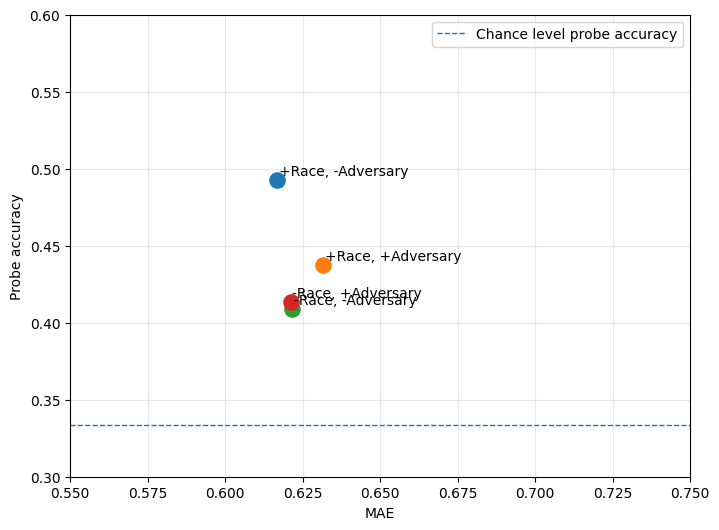

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for _, row in summary.iterrows():

    plt.scatter(
        row["Test_MAE"],
        row["Test_Probe"],
        s=120
    )

    plt.text(
        row["Test_MAE"] + 0.0005,
        row["Test_Probe"] + 0.003,
        row["Model"],
        fontsize=10
    )

plt.axhline(
    chance,
    linestyle="--",
    linewidth=1,
    label="Chance level probe accuracy"
)

plt.xlabel("MAE")
plt.ylabel("Probe accuracy")

plt.grid(True, alpha=0.3)
plt.legend()

plt.xlim(0.55, 0.75)
plt.ylim(0.30, 0.60)

plt.show()